# **Análisis Demográfico**

**Responsabilidades:**

*   Explorar las columnas básicas de demografía
*   Crear visualizaciones simples de edad, género, rango
*   Documentar hallazgos principales


In [41]:
#Demografia basica.py
#Librerias
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
import seaborn as sns

In [6]:
#Conectar a drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Leer los datos
df = pd.read_excel('/content/drive/MyDrive/Python/JEFAB_2024_limpio.xlsx')

In [9]:
# Explorar estructura básica
print("=== INFORMACIÓN GENERAL ===")
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

=== INFORMACIÓN GENERAL ===
Total de registros: 6423
Total de columnas: 61


# **Preguntas**
1. ¿Cuál es el rango de edad más común?
2. ¿Hay diferencias en la distribución por género?
3. ¿Cuál es el grado militar más frecuente?

# **1. ¿Cuál es el rango de edad más común?**

In [10]:
#  1.¿Cuál es el rango de edad más común?
# Retomamos el analisis de edad
print("\n=== RANGO DE EDAD MÁS COMÚN ===")
print("Promedio:", df['EDAD2'].mean().round(1))
print("Mínima:", df['EDAD2'].min())
print("Máxima:", df['EDAD2'].max())


=== RANGO DE EDAD MÁS COMÚN ===
Promedio: 36.7
Mínima: 18.0
Máxima: 69.0


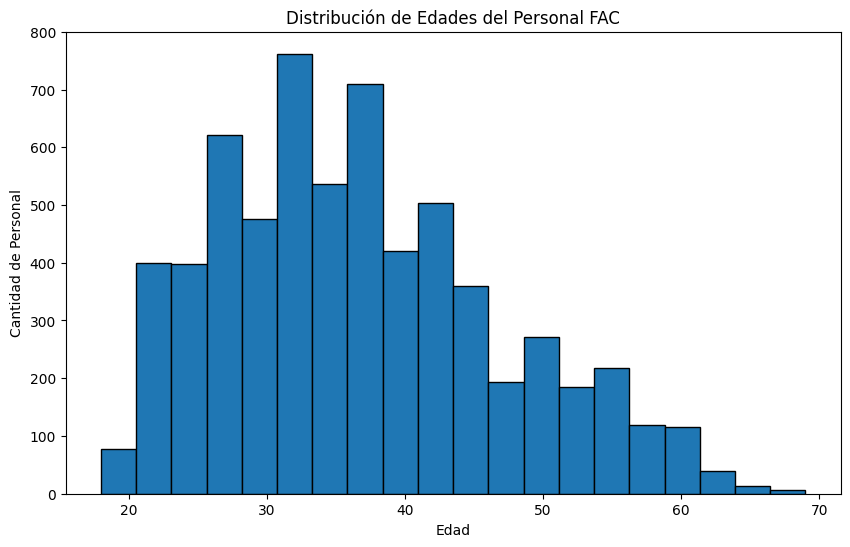

In [11]:
# Gráfico de edades
plt.figure(figsize=(10, 6))
plt.hist(df['EDAD2'], bins=20, edgecolor='black')
plt.title('Distribución de Edades del Personal FAC')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Personal')
plt.show()

In [18]:
# --- Transformar EDAD_RANGO ---
def transformar_rango(valor):
    if pd.isna(valor):
        return None
    val_str = str(valor)
    if len(val_str) == 4:  # ej: "1822"
        return f"{val_str[:2]}-{val_str[2:]}"
    elif len(val_str) == 5:  # ej: "3842"
        return f"{val_str[:2]}-{val_str[2:]}"
    return val_str

df["EDAD_RANGO_LIMPIO"] = df["EDAD_RANGO"].apply(transformar_rango)

In [19]:
# Con la columna EDAD_RANGO ya categorizada
print("Rango más común:", df['EDAD_RANGO_LIMPIO'].mode()[0])
print(df['EDAD_RANGO_LIMPIO'].value_counts())

Rango más común: 33-37
EDAD_RANGO_LIMPIO
33-37    1267
28-32    1211
38-42    1012
23-27     958
43-47     601
48-52     470
53-57     371
18-22     309
58-62     194
63-67      26
68-72       4
Name: count, dtype: int64


In [20]:
print("\n=== PROPORCION POR RANGO DE EDAD ===")
print(df['EDAD_RANGO_LIMPIO'].value_counts(normalize=True) * 100)


=== PROPORCION POR RANGO DE EDAD ===
EDAD_RANGO_LIMPIO
33-37    19.725985
28-32    18.854118
38-42    15.755877
23-27    14.915149
43-47     9.356998
48-52     7.317453
53-57     5.776117
18-22     4.810836
58-62     3.020395
63-67     0.404795
68-72     0.062276
Name: proportion, dtype: float64


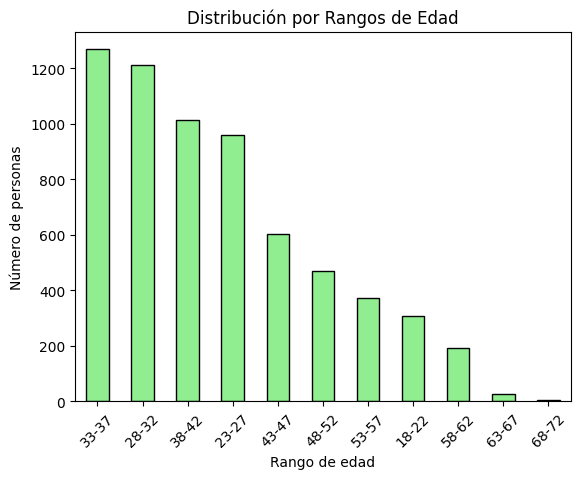

In [21]:
# Gráfico
df['EDAD_RANGO_LIMPIO'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Distribución por Rangos de Edad")
plt.xlabel("Rango de edad")
plt.ylabel("Número de personas")
plt.xticks(rotation=45)
plt.show()

De esta manera podemos indicar que el rango de edad mas comun en nuestra base de datos es de 33-37 años con una edad promedio de 36.7 años

# **2. ¿Hay diferencias en la distribución por género?**

In [22]:
# 2. ¿Hay diferencias en la distribución por género?
print("\n=== DISTRIBUCIÓN POR GÉNERO ===")
print(df['GENERO'].value_counts(normalize=True) * 100)


=== DISTRIBUCIÓN POR GÉNERO ===
GENERO
MASCULINO     69.297836
FEMENINO      30.437490
OTRO           0.233536
NO BINARIO     0.031138
Name: proportion, dtype: float64


In [23]:
# Análisis de género
print("\n=== ANÁLISIS DE GÉNERO ===")
print(df['GENERO'].value_counts())


=== ANÁLISIS DE GÉNERO ===
GENERO
MASCULINO     4451
FEMENINO      1955
OTRO            15
NO BINARIO       2
Name: count, dtype: int64


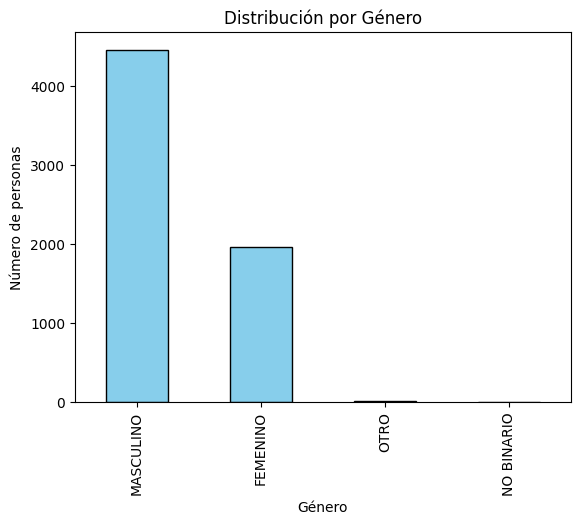

In [24]:
# Gráfico
df['GENERO'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribución por Género")
plt.xlabel("Género")
plt.ylabel("Número de personas")
plt.show()

En cuanto a la variable género, se observa un claro predominio del genero masculino dentro de la muestra, seguido por el femenino en menor proporción. Las categorías “Otro” y “No binario” tienen una baja participación.

# **3. ¿Cuál es el grado militar más frecuente?**

In [25]:
# 3. ¿Cuál es el grado militar más frecuente?
print("\n=== GRADO MILITAR MÁS FRECUENTE ===")
print("Grado más frecuente:", df['GRADO'].mode()[0])
print(df['GRADO'].value_counts().head())


=== GRADO MILITAR MÁS FRECUENTE ===
Grado más frecuente: NO RESPONDE
GRADO
NO RESPONDE    1929
T3              622
T2              621
T1              491
CT              483
Name: count, dtype: int64


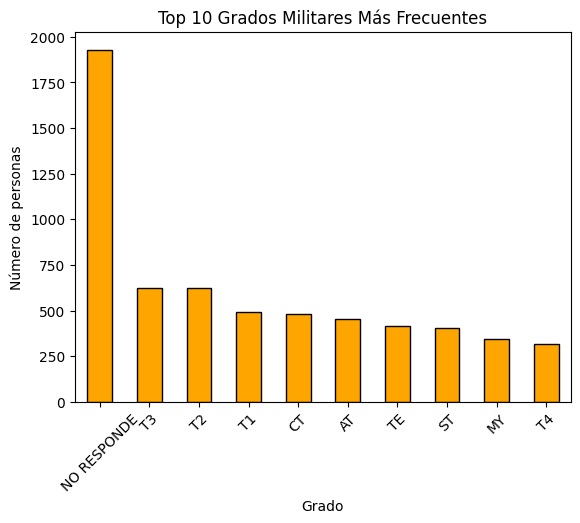

In [26]:
# Gráfico
df['GRADO'].value_counts().head(10).plot(kind='bar', color='orange', edgecolor='black')
plt.title("Top 10 Grados Militares Más Frecuentes")
plt.xlabel("Grado")
plt.ylabel("Número de personas")
plt.xticks(rotation=45)
plt.show()

La categoría más frecuente fue “No responde”, lo que evidencia un vacío de información en los registros. Entre quienes reportaron su rango, predominan los grados técnicos (T3 y T2), lo cual refleja que gran parte del personal encuestado corresponde a suboficiales técnicos en diferentes niveles. Los grados de oficiales aparecen en menor proporción.

In [27]:
# Revisar relación entre CATEGORIA y GRADO
pd.crosstab(df['CATEGORIA'], df['GRADO']).head(10)

GRADO,AT,BG,CR,CT,GR,MG,MY,NO RESPONDE,ST,T1,T2,T3,T4,TC,TE,TJ,TJC,TS
CATEGORIA,,,,,,,,,,,,,,,,,,
CIVIL,0,0,0,0,0,0,0,1929,0,0,0,0,0,0,0,0,0,0
OFICIAL,0,5,47,483,1,1,343,0,406,1,0,1,0,140,416,0,0,0
SUBOFICIAL,453,0,1,0,0,1,0,0,0,490,621,621,319,0,0,61,11,72


In [28]:
# Revisar porcentaje de "No responde" por CATEGORIA
no_responde = df[df['GRADO'] == "NO RESPONDE"]
print(no_responde['CATEGORIA'].value_counts(normalize=True) * 100)

CATEGORIA
CIVIL    100.0
Name: proportion, dtype: float64


En el análisis del grado militar se observa que la categoría “No responde” corresponde en su totalidad a personal clasificado como “CIVIL”. Por lo tanto, esta ausencia no debe interpretarse como un dato faltante, sino como un valor no aplicable para este grupo, ya que los civiles no tienen rango militar

T-test: t=-9.91, p=0.0000


/tmp/ipython-input-1334626971.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="GENERO", y="EDAD2", data=df, palette="Set2")


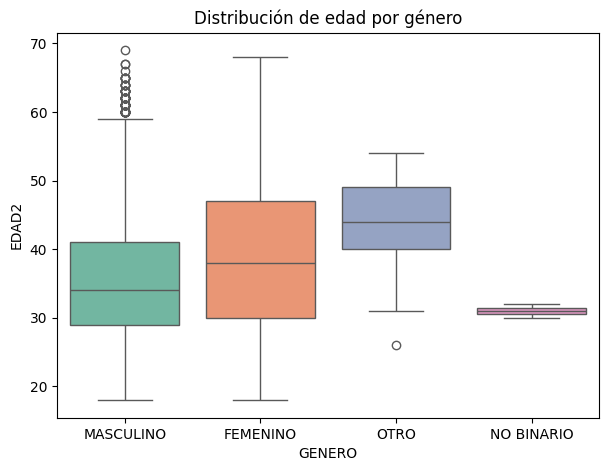

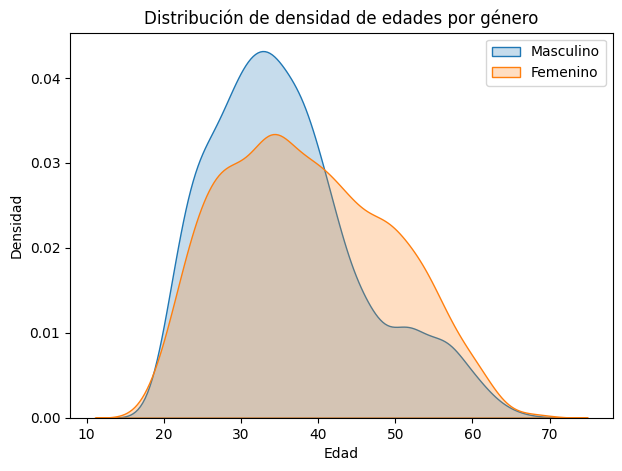

In [57]:
# --- Análisis estadístico ---

# T-test Edad según Género
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar datos
edades_m = df.loc[df["GENERO"]=="MASCULINO", "EDAD2"].dropna()
edades_f = df.loc[df["GENERO"]=="FEMENINO", "EDAD2"].dropna()

# T-test
t_stat, p_val = ttest_ind(edades_m, edades_f, equal_var=False)
print(f"T-test: t={t_stat:.2f}, p={p_val:.4f}")

# Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(x="GENERO", y="EDAD2", data=df, palette="Set2")
plt.title("Distribución de edad por género")
plt.show()

# KDE
plt.figure(figsize=(7,5))
sns.kdeplot(data=edades_m, label="Masculino", fill=True)
sns.kdeplot(data=edades_f, label="Femenino", fill=True)
plt.title("Distribución de densidad de edades por género")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.legend()
plt.show()

T-test (Edad por género)

t = –9.91, p < 0.001

Segun lo obtenido, existe una diferencia estadísticamente significativa entre la edad promedio de hombres y mujeres. El signo negativo indica que los hombres presentan, en promedio, una edad menor que las mujeres.

Correlación Spearman Edad-Estrato: rho=0.07, p=0.0000
Kruskal-Wallis Edad vs Estrato: H=62.15, p=0.0000


/tmp/ipython-input-1317803225.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ESTRATO", y="EDAD2", data=df, palette="Set3")


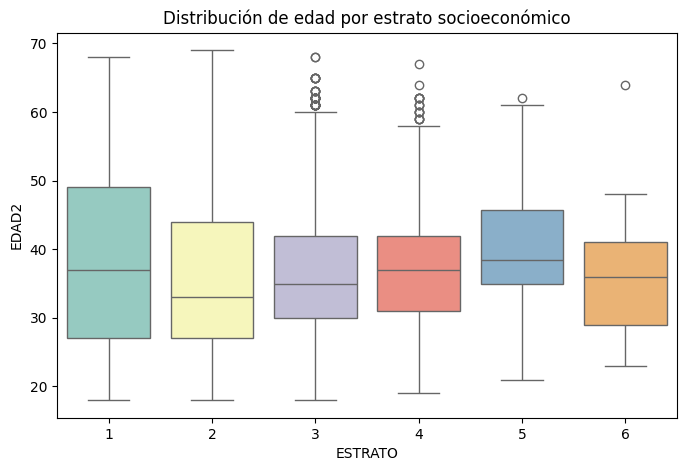

In [58]:
from scipy.stats import spearmanr, kruskal

# Spearman
corr_spear, p_spear = spearmanr(df["EDAD2"], df["ESTRATO"])
print(f"Correlación Spearman Edad-Estrato: rho={corr_spear:.2f}, p={p_spear:.4f}")

# Kruskal-Wallis
grupos = [grupo["EDAD2"].dropna() for _, grupo in df.groupby("ESTRATO")]
stat, p = kruskal(*grupos)
print(f"Kruskal-Wallis Edad vs Estrato: H={stat:.2f}, p={p:.4f}")

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="ESTRATO", y="EDAD2", data=df, palette="Set3")
plt.title("Distribución de edad por estrato socioeconómico")
plt.show()


**Correlación Spearman (Edad–Estrato)**

ρ = 0.07, p < 0.001

La relación entre edad y estrato es positiva pero muy débil. Esto significa que, aunque a mayor estrato la edad tiende a ser ligeramente mayor, el efecto es mínimo.

**Kruskal-Wallis (Edad vs Estrato)**

H = 62.15, p < 0.001

Existen diferencias significativas en la distribución de edad entre los distintos estratos socioeconómicos. Sin embargo, el tamaño del efecto parece pequeño, por lo que la magnitud práctica de la diferencia es limitada.

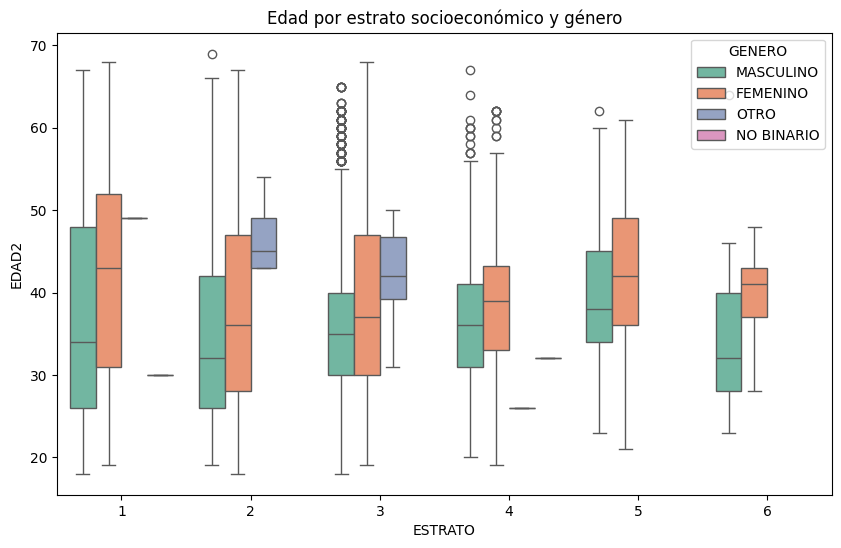

In [60]:
# Boxplots segmentados (Edad por estrato separado por género)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="ESTRATO", y="EDAD2", hue="GENERO", data=df, palette="Set2")
plt.title("Edad por estrato socioeconómico y género")
plt.show()


La gráfica muestra que, en todos los estratos socioeconómicos, las mujeres tienden a tener una edad promedio ligeramente mayor que los hombres. Además, se observa que la dispersión de edades es más amplia en los estratos 1 y 2, mientras que en los estratos más altos 5 y 6 las edades tienden a concentrarse en un rango menor. Esto sugiere que tanto el género como el estrato influyen en la distribución de la edad, con patrones diferenciados según el grupo analizado.